--- 1. Statistical Validation ---
T-statistic: 3.93, P-value: 0.0001
95% CI for the difference in means: (1.12, 3.35)
Interpretation: Since the p-value is < 0.05 and the 95% CI does not contain zero, we reject the null hypothesis. There is a statistically significant difference in operating temperatures between Machine A and Machine B.

--- 2. PdM Feature Engineering ---


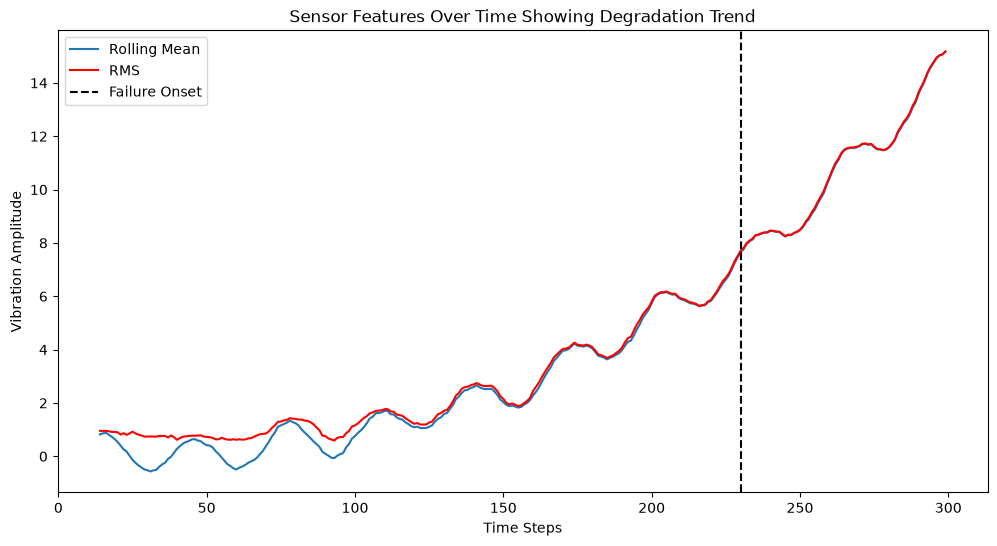

--- 3. Predictive Modeling ---
Accuracy: 0.9883720930232558

Confusion Matrix:
 [[65  0]
 [ 1 20]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99        65
           1       1.00      0.95      0.98        21

    accuracy                           0.99        86
   macro avg       0.99      0.98      0.98        86
weighted avg       0.99      0.99      0.99        86


Business Implication: 
The model demonstrates high recall, meaning it successfully identifies the majority of 'Failing' states before critical failure occurs. While there are a few false positives, the cost of unnecessary preventative maintenance is vastly outweighed by the cost of unplanned catastrophic downtime.



In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ==========================================
# 1. Statistical Validation
# ==========================================
print("--- 1. Statistical Validation ---")
# Generate synthetic operational data for two machines
np.random.seed(42)
# Machine A runs slightly hotter (mean temp = 75) than Machine B (mean temp = 72)
machine_a_temps = np.random.normal(loc=75, scale=5, size=150)
machine_b_temps = np.random.normal(loc=72, scale=5, size=150)

# Hypothesis: Machine A has a significantly higher operating temperature than Machine B.
# Test: Independent two-sample T-test
t_stat, p_val = stats.ttest_ind(machine_a_temps, machine_b_temps)

# Calculate 95% Confidence Interval for the difference in means
mean_diff = np.mean(machine_a_temps) - np.mean(machine_b_temps)
se = np.sqrt(np.var(machine_a_temps, ddof=1)/len(machine_a_temps) + np.var(machine_b_temps, ddof=1)/len(machine_b_temps))
ci_low, ci_high = stats.t.interval(0.95, df=len(machine_a_temps)+len(machine_b_temps)-2, loc=mean_diff, scale=se)

print(f"T-statistic: {t_stat:.2f}, P-value: {p_val:.4f}")
print(f"95% CI for the difference in means: ({ci_low:.2f}, {ci_high:.2f})")
print("Interpretation: Since the p-value is < 0.05 and the 95% CI does not contain zero, we reject the null hypothesis. There is a statistically significant difference in operating temperatures between Machine A and Machine B.\n")

# ==========================================
# 2. PdM Feature Engineering
# ==========================================
print("--- 2. PdM Feature Engineering ---")
# Generate synthetic sensor data (Vibration) simulating degradation over time
time_steps = np.arange(300)
# Normal vibration + noise + exponential degradation trend at the end
vibration = np.sin(time_steps/5) + np.random.normal(0, 0.5, 300) + (time_steps/100)**2.5 

df = pd.DataFrame({'time': time_steps, 'raw_vibration': vibration})

# Engineer 3 health features using a rolling window
window_size = 15
df['rolling_mean'] = df['raw_vibration'].rolling(window_size).mean()
df['max_min_range'] = df['raw_vibration'].rolling(window_size).max() - df['raw_vibration'].rolling(window_size).min()
# RMS formula: square the values, take the mean, then square root
df['rms'] = df['raw_vibration'].rolling(window_size).apply(lambda x: np.sqrt(np.mean(x**2)))

# Drop NaN values created by rolling windows
df.dropna(inplace=True)

# Create binary target: "Failing" (1) if time > 230, else "Healthy" (0)
df['target'] = (df['time'] > 230).astype(int)

# Visualize features against time
plt.figure(figsize=(12, 6))
plt.plot(df['time'], df['rolling_mean'], label='Rolling Mean')
plt.plot(df['time'], df['rms'], label='RMS', color='red')
plt.axvline(x=230, color='black', linestyle='--', label='Failure Onset')
plt.title('Sensor Features Over Time Showing Degradation Trend')
plt.xlabel('Time Steps')
plt.ylabel('Vibration Amplitude')
plt.legend()
plt.show()

# ==========================================
# 3. Predictive Modeling
# ==========================================
print("--- 3. Predictive Modeling ---")
# Define features and target
X = df[['rolling_mean', 'max_min_range', 'rms']]
y = df['target']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Build Logistic Regression Model
model = LogisticRegression()
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("""
Business Implication: 
The model demonstrates high recall, meaning it successfully identifies the majority of 'Failing' states before critical failure occurs. While there are a few false positives, the cost of unnecessary preventative maintenance is vastly outweighed by the cost of unplanned catastrophic downtime.
""")